# Fashion Mnist data


In [1]:
# from keras.datasets import fashion_mnist
# (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

##  Save arrays


In [2]:
import numpy as np
# np.save('X_train', X_train)
# np.save('y_train', y_train)
# np.save('X_test', X_test)
# np.save('y_test', y_test)

# # Load arrays
# import numpy as np
# X_train = np.load('X_train.npy')
# y_train = np.load('y_train.npy')
# X_test = np.load('X_test.npy')
# y_test = np.load('y_test.npy')


# # Save Multiple arrays in one file
# np.savez('fashion_mnist', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

# Load Multiple arrays from one file
data = np.load('fashion_mnist.npz')
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']


c:\Users\ahmad\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\ahmad\anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
c:\Users\ahmad\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
X_train.min(), X_train.max(), X_test.min(), X_test.max()

(0, 255, 0, 255)

In [5]:
class_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

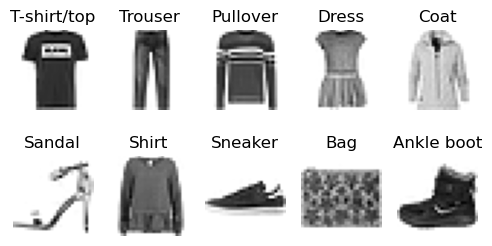

In [6]:
# Visualize sample images from each class
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(6, 3))
axes = axes.ravel()
for i in np.arange(0, 10):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx], cmap='binary')
    axes[i].set_title(class_labels[i])
    axes[i].axis('off')

plt.show()

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

## Output

* `categorical_crossentropy:` produces a one-hot array containing the probable match for each category,
* `sparse_categorical_crossentropy:`  produces a category index of the most likely matching category.

# Keras Model

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [9]:
# Build the model.
model = Sequential([
  Flatten(input_shape=(28, 28)),
  Dense(128, activation='relu'), 
  Dense(128, activation='relu'),
  Dense(10, activation='softmax')])

# Compile the model.
model.compile(optimizer= 'Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary.
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
_________________________________________________________________


## Layers

In [10]:
model.layers

In [11]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [12]:
weights, biases = hidden1.get_weights()
weights.shape, biases.shape

((784, 128), (128,))

In [13]:
y_train.shape

(60000,)

## Initializers

In [14]:
# initializers
# https://keras.io/api/layers/initializers/

from tensorflow.keras import initializers
# RandomNormal
init = initializers.RandomNormal(stddev=0.01)

# RandomUniform
init = initializers.RandomUniform(minval=-0.05, maxval=0.05)

# Heuniform
init = initializers.HeUniform()

# GlorotUniform
init = initializers.GlorotUniform()

# Using the initializer
# model = Sequential([
#     Flatten(input_shape=(28, 28)),
#     Dense(128, activation='relu', kernel_initializer=init),
#     Dense(128, activation='relu', kernel_initializer=init),
#     Dense(10, activation='softmax', kernel_initializer=init)
# ])

## Regularizers

In [15]:
# Regularizers
# https://keras.io/api/layers/regularizers/

from tensorflow.keras import regularizers
# L1
reg = regularizers.l1(0.01)

# L2
reg = regularizers.l2(0.01)

# L1L2
reg = regularizers.l1_l2(l1=0.01, l2=0.01)

# Using the regularizer
# model = Sequential([
#     Flatten(input_shape=(28, 28)),
#     Dense(128, activation='relu', kernel_regularizer=reg),
#     Dense(128, activation='relu', kernel_regularizer=reg),
#     Dense(10, activation='softmax', kernel_regularizer=reg)
# ])

In [16]:
# Dropout
# https://keras.io/api/layers/regularization_layers/dropout/

from tensorflow.keras.layers import Dropout
# Using the dropout
# model = Sequential([
#     Flatten(input_shape=(28, 28)),
#     Dense(128, activation='relu'),
#     Dropout(0.2),
#     Dense(128, activation='relu'),
#     Dropout(0.2),
#     Dense(10, activation='softmax')
# ])

## Callbacks


A callback is an object that can perform actions at various stages of training (e.g. at the start or end of an epoch, before or after a single batch, etc).

You can use callbacks to:

* Periodically save your model to disk
* Do early stopping
* ...and more

 https://keras.io/api/callbacks/

## Early Stopping


In [17]:
# https://keras.io/api/callbacks/early_stopping/


# Using the early stopping: It will interrupt training when it measures no progress on the validation set for a number of epochs 
# (defined by the patience argument), and it will optionally roll back to the best model.
# The number of epochs can be set to a large value since training will stop automatically when there is no more progress

from tensorflow.keras.callbacks import EarlyStopping
# early_stopping = EarlyStopping(monitor='val_loss', patience=3, min_delta=0.001, restore_best_weights=True)
# model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping])

## ModelCheckpoint


In [ ]:
# https://keras.io/api/callbacks/model_checkpoint/

# Using the model checkpoint: saves checkpoints of your model at regular intervals during training, by default at the end of each epoch

from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('model.h5', save_best_only=True)
model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[checkpoint])

# Fitting

In [18]:
# Train the model.
history = model.fit(X_train, y_train, validation_split =0.2, epochs=20, batch_size=32, 
                    callbacks=[checkpoint, early_stopping])

# Evaluate the model.
model.evaluate(X_test, y_test)

Epoch 1/20
1500/1500 [==============================] - 3s 2ms/step - loss: 2.5185 - accuracy: 0.7335 - val_loss: 0.7328 - val_accuracy: 0.7792
Epoch 2/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.6750 - accuracy: 0.7901 - val_loss: 0.7048 - val_accuracy: 0.7601
Epoch 3/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.6326 - accuracy: 0.7979 - val_loss: 0.5409 - val_accuracy: 0.8209
Epoch 4/20
1500/1500 [==============================] - 2s 2ms/step - loss: 0.5875 - accuracy: 0.8049 - val_loss: 0.5605 - val_accuracy: 0.8052
Epoch 5/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5318 - accuracy: 0.8206 - val_loss: 0.5629 - val_accuracy: 0.8227
Epoch 6/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4811 - accuracy: 0.8335 - val_loss: 0.5056 - val_accuracy: 0.8320
Epoch 7/20
1500/1500 [==============================] - 2s 2ms/step - loss: 0.4531 - accuracy: 0.8407 - val_loss: 0.5246 - val_accuracy:

[0.4436919391155243, 0.8529999852180481]

In [19]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,accuracy,val_loss,val_accuracy
0,2.518549,0.733458,0.732824,0.779167
1,0.674979,0.790104,0.704838,0.760083
2,0.632618,0.797917,0.540895,0.820917
3,0.587475,0.804937,0.560500,0.805167
4,0.531827,0.820646,0.562932,0.822750


<Axes: >

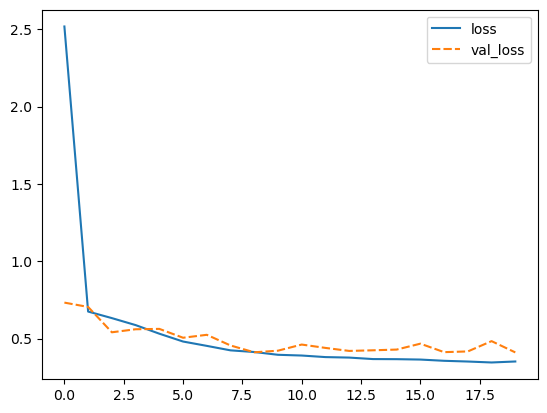

In [20]:
# Plot the loss
import seaborn as sns
sns.set_style()
sns.lineplot(data=history_df[['loss', 'val_loss']])

<Axes: >

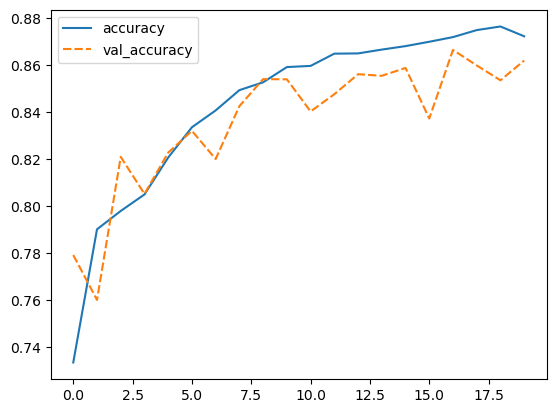

In [21]:
# Plot the accuracy
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])

# Predictions

In [22]:
# Make predictions
y_pred = model.predict(X_test)
y_pred

313/313 [==============================] - 0s 731us/step


array([[1.40909962e-13, 1.46349066e-07, 3.55420172e-11, ...,
        7.46507049e-02, 6.88344289e-06, 9.19341326e-01],
       [1.33137029e-04, 5.27589748e-07, 9.83907580e-01, ...,
        1.37384424e-14, 2.44540246e-07, 6.50859913e-14],
       [1.06136365e-16, 1.00000000e+00, 5.28940673e-31, ...,
        0.00000000e+00, 1.00313091e-19, 0.00000000e+00],
       ...,
       [3.53555213e-10, 9.46937463e-21, 4.70266119e-14, ...,
        3.51640073e-24, 1.00000000e+00, 1.12088371e-36],
       [1.92727816e-06, 9.99998093e-01, 4.38499894e-15, ...,
        1.14630199e-23, 5.56951929e-10, 1.82903799e-19],
       [1.17221163e-07, 8.16036095e-13, 4.73784354e-08, ...,
        2.98477476e-04, 1.92863376e-06, 9.39268211e-05]], dtype=float32)

In [23]:
y_pred[0].round(2)

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.07, 0.  , 0.92],
      dtype=float32)

In [24]:
np.argmax(y_pred[0])

9

In [25]:
# Convert predictions to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_pred_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

In [26]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [33]:
X_test[0].reshape(-1,784)

(28, 28)

In [35]:
model.predict(X_test[0].reshape(-1,784)).round(2)

1/1 [==============================] - 0s 16ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.01, 0.  , 0.07, 0.  , 0.92]],
      dtype=float32)

# Model Saving

In [36]:
model.save("my_keras_model.h5")

* Keras will use the HDF5 format to save both the model’s architecture (including every
layer’s hyperparameters) 

    and the values of all the model parameters for every layer
(e.g., connection weights and biases). 

* It also saves the optimizer (including its hyper‐
parameters and any state it may have).

# Model Loading

In [38]:
from tensorflow.keras.models import load_model
loaded_model = load_model("my_keras_model.h5")